In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path
from torchvision.datasets.utils import download_url
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent.parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions import graph_print_analysis as gp_tool
    from train_mnist_with_network import HBModel_MNIST as hbm

finally:
    sys.path = _old_sys_path



Project root added to sys.path: c:\Users\ASUS\Desktop\cone_dynamics


In [2]:
num_epochs = 2
lr = 1e-2
if_decay = True
batch_sizes = {16, 32, 64, 128, 256, 512, 1024}
batch_size=8192
steps = {200, 400, 800, 1200, 1600, 2000}
step=1000
lrs={1e-4,1e-3, 1e-2, 1e-1}
decays={0, 1e-3, 1e-1}
if_regularize=True

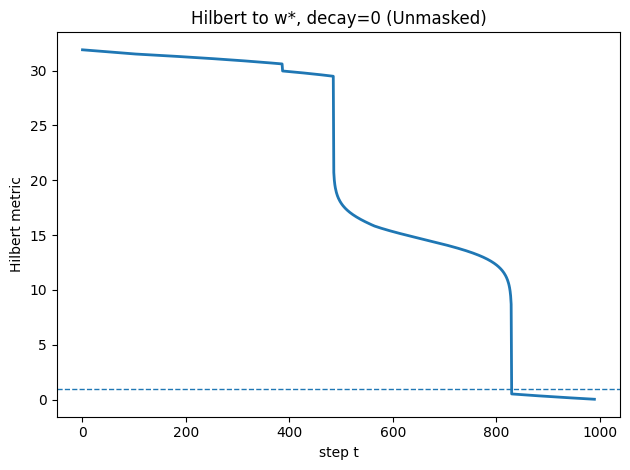

===== Hilbert Metric Statistics =====

The first 200 steps:
  Mean ≈ 31.5436
  Min ≈ 31.2449, Max ≈ 31.8926
  Q25 ≈ 31.3843, Q75 ≈ 31.7073

The 200 to 400 steps:
  Mean ≈ 30.8769
  Min ≈ 29.9099, Max ≈ 31.2420
  Q25 ≈ 30.7507, Q75 ≈ 31.0923

The last 200 steps:
  Mean ≈ 2.4670
  Min ≈ 0.0264, Max ≈ 12.5835
  Q25 ≈ 0.1635, Q75 ≈ 0.4739



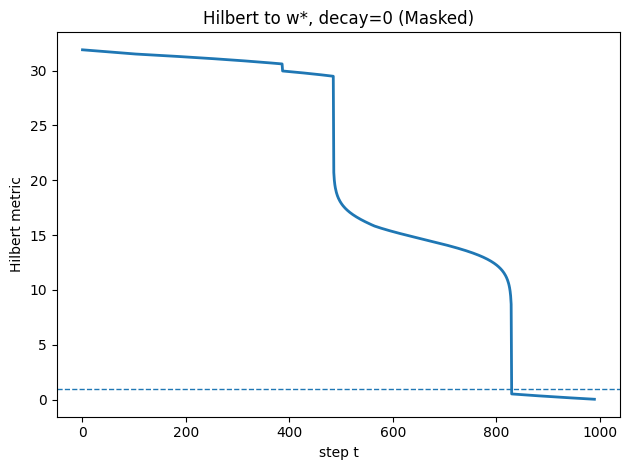

===== Hilbert Metric Statistics =====

The first 200 steps:
  Mean ≈ 31.5436
  Min ≈ 31.2449, Max ≈ 31.8926
  Q25 ≈ 31.3843, Q75 ≈ 31.7073

The 200 to 400 steps:
  Mean ≈ 30.8769
  Min ≈ 29.9099, Max ≈ 31.2420
  Q25 ≈ 30.7507, Q75 ≈ 31.0923

The last 200 steps:
  Mean ≈ 2.4670
  Min ≈ 0.0264, Max ≈ 12.5835
  Q25 ≈ 0.1635, Q75 ≈ 0.4739



KeyboardInterrupt: 

In [ ]:
unmasks={}
for decay in decays:
    res=hbm.train_with_optional_initialization(num_steps=step,
        sample_size=batch_size,
        lr=lr,
        if_decay=if_decay,
        number_of_layerss=20,
        if_initialize=True,regularization_coeff=decay,seed=1919810)
    trajec=res['param_traj']
    w_star=trajec[-1]
    trajec=trajec[:-10]
    analysis_result=gp_tool.analysis_to_w_star(trajectory=trajec, w_star=w_star, if_show=True, if_print=True, if_save=False, if_writes=True, plt_title=f"Hilbert to w*, decay={decay}", if_masked=True,if_smooth=False)
    unmasks[decay]=analysis_result

In [ ]:
print(unmasks.keys())
trajehe3=unmasks[1e-3]
print(trajehe3)

dict_keys([0, 0.1, 0.001])
{'hilbert_to_w_star': [31.878545058237957, 31.875012546455434, 31.871472602935942, 31.867925124808046, 31.86437014470457, 31.860807558747272, 31.85723733066947, 31.853659354829503, 31.850073663017163, 31.846480218133763, 31.842878912948095, 31.83926970903758, 31.83565263804076, 31.832027591092825, 31.82839452887728, 31.824753411771862, 31.821104199845326, 31.81744685285414, 31.81378133023917, 31.810107518944392, 31.806425376970545, 31.802734934694985, 31.79903607727092, 31.79532876168679, 31.791612944584628, 31.787888582256258, 31.784155630639443, 31.78041397096073, 31.776663632232523, 31.772904569301677, 31.76913666144849, 31.76535986192198, 31.76157419934966, 31.757779551007204, 31.753975792623915, 31.750162951634106, 31.746340979297933, 31.742509826464076, 31.738669443565016, 31.734819702790443, 31.730960552823323, 31.72709202032997, 31.72321397528775, 31.719326365043326, 31.7154291364855, 31.711522236039837, 31.7076055296944, 31.70367904227125, 31.6997427

In [ ]:
from matplotlib import pyplot as plt
